# heatwaves_Hobday2016_obs.ipynb
## Calculate marine heatwaves with Observations using the method outlined in Hobday et al. 2016

#### Created by Brendan Myers
##### 09/02/2026

In [2]:
%matplotlib inline
# import warnings
# warnings.filterwarnings('ignore')
import os
from glob import glob
from collections import OrderedDict
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs

import pandas as pd

import xesmf #for regridding
xr.set_options(keep_attrs=True)
import regionmask #for generating 1° ocean mask
# import m6toolbox

import xmhw

### Make a standard 1° ones masks for masking, etc. (one for lons -180 to 180 and one for lons 0 to 360)

In [3]:
ones2 = np.full((180,360),1,dtype=int)
ones2 = xr.DataArray(ones2,dims=('lat','lon'))
ones2['lat'] = np.arange(-89.5, 90, 1)
ones2['lon'] = np.arange(0.5, 360, 1)

### Read in the standard 1° basin mask

In [4]:
# Define the 1-degree latitude and longitude points
lon = np.arange(-179.5, 180, 1)
lat = np.arange(-89.5, 90, 1)

# Create the land mask using Natural Earth data (default resolution is 1:110m)
# The mask will be boolean (True for land) on the specified grid
land_mask = regionmask.defined_regions.natural_earth_v5_1_2.land_110.mask(lon, lat)
land_mask = land_mask.where(land_mask==0, other=1)

In [5]:
ones = np.full((180,360),1,dtype=int)
ones = xr.DataArray(ones,dims=('lat','lon'))
ones['lat'] = np.arange(-89.5, 90, 1)
ones['lon'] = np.arange(-179.5, 180, 1)
ones = ones.where(land_mask == 1)

In [7]:
### forth, get the major basins mask, created using 'make_major_basins_mask.ipynb'
major_basins = xr.open_dataset('../tools/major_basins_1x1.nc')

major_basins = major_basins.basin.values
major_basins = xr.DataArray(major_basins, dims=('lat','lon'))

# Read in observational data monthly climatologies that have been regridded to 1°

In [8]:
file = '../tools/Obs4biomes.nc'
ds_obs = xr.open_dataset(file)

In [9]:
ds_obs

<xarray.Dataset> Size: 25MB
Dimensions:  (lat: 180, lon: 360, month: 12)
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * month    (month) float64 96B 1.0 2.0 3.0 4.0 5.0 ... 8.0 9.0 10.0 11.0 12.0
Data variables:
    MLD      (lat, lon, month) float64 6MB ...
    Chl      (lat, lon, month) float64 6MB ...
    Ice      (lat, lon, month) float64 6MB ...
    SST      (lat, lon, month) float64 6MB ...

# A few precalculations....

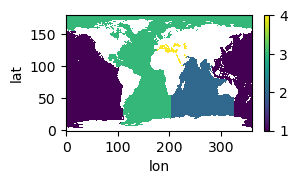

In [10]:
major_basins.plot(figsize=(3,1.5))

### Assign basins

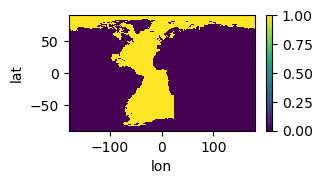

In [11]:
Atlantic = ones.where(major_basins == 3, other=0)
#.where(major_basins.basin == 3) #ones.where(ds_grid.REGION_MASK >= 5, other=0).where(ds_grid.REGION_MASK<10, other=0)
Atlantic.plot(figsize=(3,1.5))

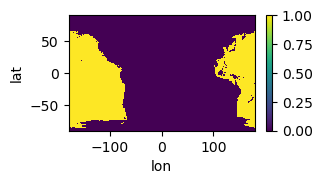

In [12]:
Pacific = ones.where(major_basins == 1, other=0)
Pacific.plot(figsize=(3,1.5))

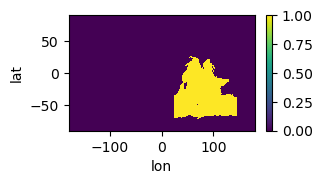

In [13]:
Indian = ones.where(major_basins == 2, other=0)
Indian.plot(figsize=(3,1.5))

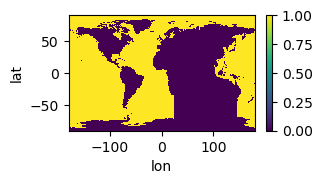

In [14]:
Atlantic_Pacific = Atlantic + Pacific
Atlantic_Pacific.plot(figsize=(3,1.5))